In [1]:
import cv2
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET
import os

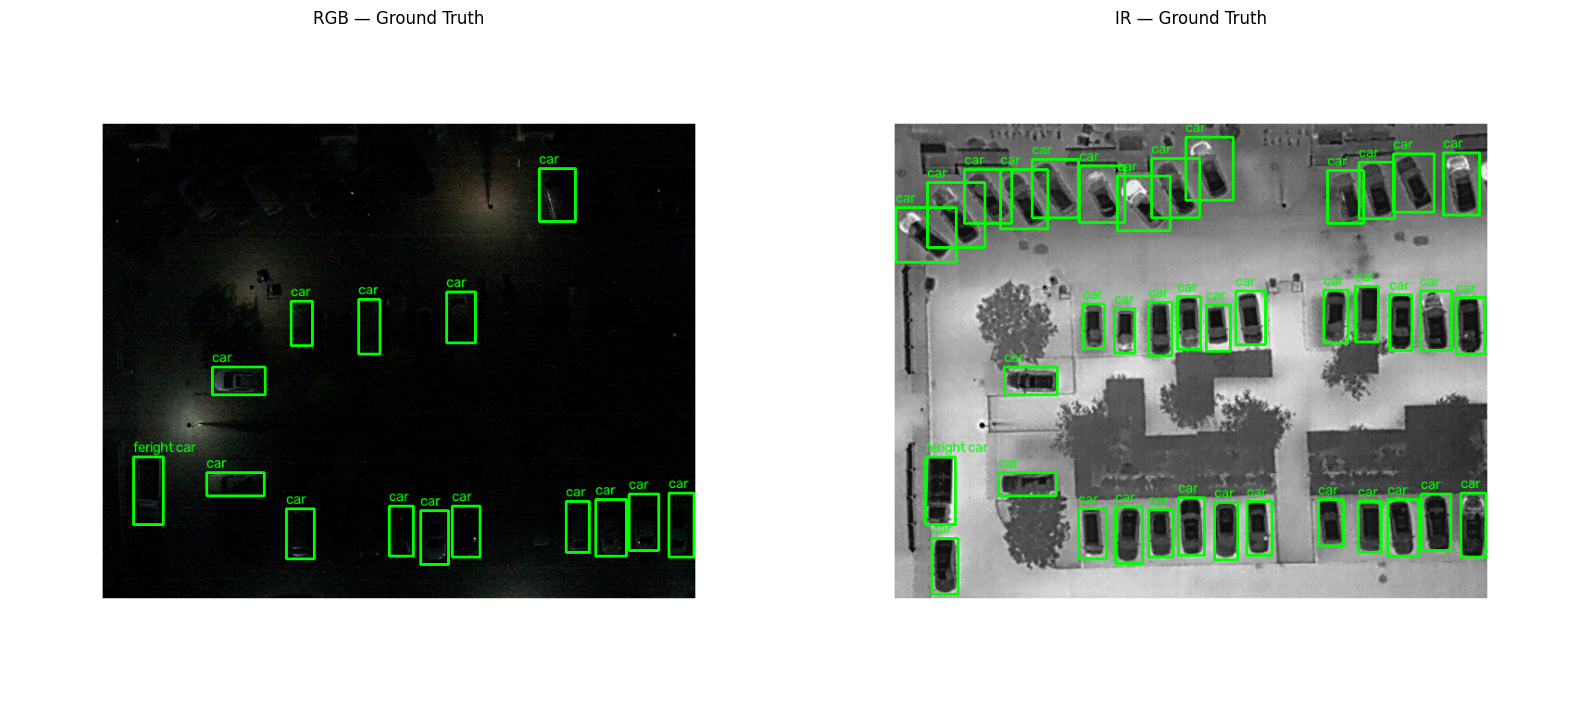

In [4]:
def load_gt_boxes(xml_path):
    """
    Load ground-truth polygons from the XML and convert them
    to axis-aligned bounding boxes.

    Returns:
        List of dictionaries containing:
        x1, y1, x2, y2, class_name
    """
    tree = ET.parse(xml_path)
    root = tree.getroot()

    boxes = []

    for obj in root.findall("object"):
        class_name = obj.find("name").text
        polygon = obj.find("polygon")

        # Get the four polygon points
        points = []
        for i in range(1, 5):
            x = int(float(polygon.find(f"x{i}").text))
            y = int(float(polygon.find(f"y{i}").text))
            points.append((x, y))

        # Convert polygon to enclosing bounding box
        xs = [point[0] for point in points]
        ys = [point[1] for point in points]

        boxes.append({
            "x1": min(xs),
            "y1": min(ys),
            "x2": max(xs),
            "y2": max(ys),
            "class_name": class_name
        })

    return boxes


def plot_gt(image_path, xml_path):
    """
    Load an image and XML ground truth, draw bounding boxes
    and labels, and return the image.
    """
    image = cv2.imread(image_path)

    if image is None:
        raise FileNotFoundError(f"Could not load image: {image_path}")

    # Convert BGR -> RGB for matplotlib
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    boxes = load_gt_boxes(xml_path)

    for box in boxes:
        x1 = box["x1"]
        y1 = box["y1"]
        x2 = box["x2"]
        y2 = box["y2"]
        class_name = box["class_name"]

        cv2.rectangle(
            image,
            (x1, y1),
            (x2, y2),
            (0, 255, 0),
            2
        )

        cv2.putText(
            image,
            class_name,
            (x1, max(y1 - 5, 15)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (0, 255, 0),
            1
        )

    return image


# ---------------------------------------------------------
# Set your RGB and IR paths here
# ---------------------------------------------------------

rgb_image_path = "./test_images/00001_rgb.jpg"
rgb_xml_path   = "./test_images/00001_rgb.xml"

ir_image_path = "./test_images/00001_ir.jpg"
ir_xml_path   = "./test_images/00001_ir.xml"


# ---------------------------------------------------------
# Load images with ground-truth detections
# ---------------------------------------------------------

rgb_image = plot_gt(
    rgb_image_path,
    rgb_xml_path
)

ir_image = plot_gt(
    ir_image_path,
    ir_xml_path
)


# ---------------------------------------------------------
# Display side-by-side
# ---------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].imshow(rgb_image)
axes[0].set_title("RGB — Ground Truth")
axes[0].axis("off")

axes[1].imshow(ir_image)
axes[1].set_title("IR — Ground Truth")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [6]:
def calculate_iou(box1, box2):
    """
    Calculate IoU between two boxes.
    Boxes are dictionaries with x1, y1, x2, y2.
    """
    x1 = max(box1["x1"], box2["x1"])
    y1 = max(box1["y1"], box2["y1"])
    x2 = min(box1["x2"], box2["x2"])
    y2 = min(box1["y2"], box2["y2"])

    intersection_width = max(0, x2 - x1)
    intersection_height = max(0, y2 - y1)
    intersection = intersection_width * intersection_height

    area1 = (box1["x2"] - box1["x1"]) * (box1["y2"] - box1["y1"])
    area2 = (box2["x2"] - box2["x1"]) * (box2["y2"] - box2["y1"])

    union = area1 + area2 - intersection

    if union == 0:
        return 0

    return intersection / union


def draw_box(image, box, color, thickness=2):
    """Draw a bounding box and label."""
    x1 = box["x1"]
    y1 = box["y1"]
    x2 = box["x2"]
    y2 = box["y2"]
    label = box["class_name"]

    cv2.rectangle(
        image,
        (x1, y1),
        (x2, y2),
        color,
        thickness
    )

    cv2.putText(
        image,
        label,
        (x1, max(y1 - 5, 15)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        color,
        1
    )


def compare_rgb_ir_gt(rgb_image_path, rgb_xml_path, ir_image_path, ir_xml_path,
                      iou_threshold=0.5):

    # Load images
    rgb_image = cv2.imread(rgb_image_path)
    ir_image = cv2.imread(ir_image_path)

    if rgb_image is None:
        raise FileNotFoundError(f"Could not load RGB image: {rgb_image_path}")

    if ir_image is None:
        raise FileNotFoundError(f"Could not load IR image: {ir_image_path}")

    # Convert BGR -> RGB for matplotlib
    rgb_image = cv2.cvtColor(rgb_image, cv2.COLOR_BGR2RGB)
    ir_image = cv2.cvtColor(ir_image, cv2.COLOR_BGR2RGB)

    # Load GT
    rgb_boxes = load_gt_boxes(rgb_xml_path)
    ir_boxes = load_gt_boxes(ir_xml_path)

    # Track which IR boxes have already been matched
    matched_ir = set()

    rgb_only = []
    ir_only = []
    matched_pairs = []

    # ---------------------------------------------------------
    # Match RGB boxes to IR boxes using IoU
    # ---------------------------------------------------------

    for rgb_idx, rgb_box in enumerate(rgb_boxes):

        best_iou = 0
        best_ir_idx = None

        for ir_idx, ir_box in enumerate(ir_boxes):

            if ir_idx in matched_ir:
                continue

            # Optional: require same class
            if rgb_box["class_name"] != ir_box["class_name"]:
                continue

            iou = calculate_iou(rgb_box, ir_box)

            if iou > best_iou:
                best_iou = iou
                best_ir_idx = ir_idx

        if best_ir_idx is not None and best_iou >= iou_threshold:

            matched_ir.add(best_ir_idx)

            matched_pairs.append({
                "rgb_idx": rgb_idx,
                "ir_idx": best_ir_idx,
                "iou": best_iou
            })

        else:
            rgb_only.append(rgb_idx)

    # Any IR boxes that were never matched are IR-only
    ir_only = [
        i for i in range(len(ir_boxes))
        if i not in matched_ir
    ]

    # ---------------------------------------------------------
    # Draw RGB boxes
    # ---------------------------------------------------------

    for idx, box in enumerate(rgb_boxes):

        if idx in rgb_only:
            # RGB-only → RED
            draw_box(rgb_image, box, (255, 0, 0), 3)

        else:
            # Matched → GREEN
            draw_box(rgb_image, box, (0, 255, 0), 2)

    # ---------------------------------------------------------
    # Draw IR boxes
    # ---------------------------------------------------------

    for idx, box in enumerate(ir_boxes):

        if idx in ir_only:
            # IR-only → RED
            draw_box(ir_image, box, (255, 0, 0), 3)

        else:
            # Matched → GREEN
            draw_box(ir_image, box, (0, 255, 0), 2)

    # ---------------------------------------------------------
    # Print results
    # ---------------------------------------------------------

    print("=" * 60)
    print("RGB ↔ IR GROUND TRUTH COMPARISON")
    print("=" * 60)

    print(f"\nRGB GT objects: {len(rgb_boxes)}")
    print(f"IR GT objects:  {len(ir_boxes)}")

    print(f"\nMatched objects: {len(matched_pairs)}")
    print(f"RGB-only objects: {len(rgb_only)}")
    print(f"IR-only objects:  {len(ir_only)}")

    print("\n" + "-" * 60)
    print("MATCHED OBJECTS")
    print("-" * 60)

    for pair in matched_pairs:
        rgb_idx = pair["rgb_idx"]
        ir_idx = pair["ir_idx"]
        iou = pair["iou"]

        print(
            f"RGB [{rgb_idx}] ↔ IR [{ir_idx}] | "
            f"Label: {rgb_boxes[rgb_idx]['class_name']} | "
            f"IoU: {iou:.3f}"
        )

    print("\n" + "-" * 60)
    print("RGB-ONLY OBJECTS")
    print("-" * 60)

    for idx in rgb_only:
        box = rgb_boxes[idx]
        print(
            f"RGB [{idx}] | "
            f"Label: {box['class_name']} | "
            f"Box: ({box['x1']}, {box['y1']}) → "
            f"({box['x2']}, {box['y2']})"
        )

    print("\n" + "-" * 60)
    print("IR-ONLY OBJECTS")
    print("-" * 60)

    for idx in ir_only:
        box = ir_boxes[idx]
        print(
            f"IR [{idx}] | "
            f"Label: {box['class_name']} | "
            f"Box: ({box['x1']}, {box['y1']}) → "
            f"({box['x2']}, {box['y2']})"
        )

    # ---------------------------------------------------------
    # Display images
    # ---------------------------------------------------------

    fig, axes = plt.subplots(1, 2, figsize=(18, 8))

    axes[0].imshow(rgb_image)
    axes[0].set_title(
        f"RGB Ground Truth\n"
        f"Green: Matched | Red: RGB-only"
    )
    axes[0].axis("off")

    axes[1].imshow(ir_image)
    axes[1].set_title(
        f"IR Ground Truth\n"
        f"Green: Matched | Red: IR-only"
    )
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

RGB ↔ IR GROUND TRUTH COMPARISON

RGB GT objects: 15
IR GT objects:  39

Matched objects: 15
RGB-only objects: 0
IR-only objects:  24

------------------------------------------------------------
MATCHED OBJECTS
------------------------------------------------------------
RGB [0] ↔ IR [1] | Label: feright car | IoU: 1.000
RGB [1] ↔ IR [2] | Label: car | IoU: 1.000
RGB [2] ↔ IR [3] | Label: car | IoU: 1.000
RGB [3] ↔ IR [7] | Label: car | IoU: 0.674
RGB [4] ↔ IR [10] | Label: car | IoU: 1.000
RGB [5] ↔ IR [11] | Label: car | IoU: 1.000
RGB [6] ↔ IR [12] | Label: car | IoU: 1.000
RGB [7] ↔ IR [13] | Label: car | IoU: 1.000
RGB [8] ↔ IR [14] | Label: car | IoU: 1.000
RGB [9] ↔ IR [15] | Label: car | IoU: 0.882
RGB [10] ↔ IR [35] | Label: car | IoU: 0.764
RGB [11] ↔ IR [17] | Label: car | IoU: 0.848
RGB [12] ↔ IR [20] | Label: car | IoU: 0.811
RGB [13] ↔ IR [6] | Label: car | IoU: 0.730
RGB [14] ↔ IR [8] | Label: car | IoU: 0.802

-----------------------------------------------------------

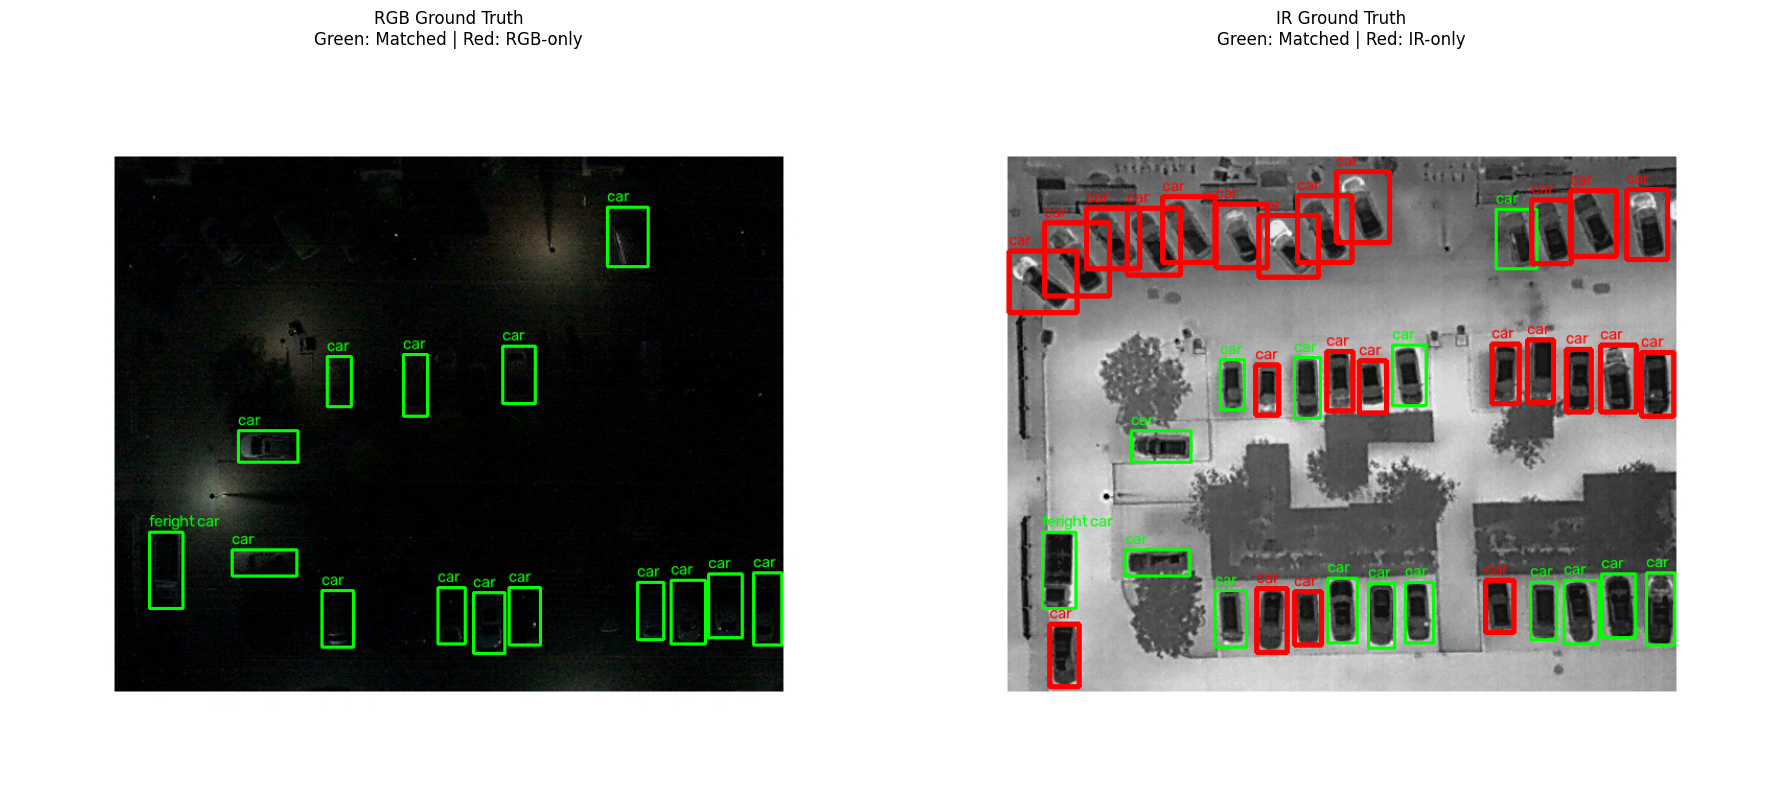

In [7]:
compare_rgb_ir_gt(
    rgb_image_path,
    rgb_xml_path,
    ir_image_path,
    ir_xml_path,
    iou_threshold=0.5
)